# Business-Oriented Exploratory Data Analysis

This notebook explores the cleaned marketing campaign dataset to identify patterns and relationships that support business decision-making.

Unlike traditional exploratory analysis, every section is aligned with predefined business questions. The objective is to investigate campaign performance, marketing efficiency, and revenue generation to support data-driven marketing decisions.

The analysis uses the cleaned dataset generated during the Data Cleaning phase.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/content/clean_campaign_data.csv",
    parse_dates=["startdate", "enddate"]
)
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   campaignid         10000 non-null  object        
 1   startdate          10000 non-null  datetime64[ns]
 2   enddate            10000 non-null  datetime64[ns]
 3   channel            10000 non-null  object        
 4   impressions        10000 non-null  int64         
 5   clicks             10000 non-null  int64         
 6   leads              10000 non-null  int64         
 7   conversions        10000 non-null  int64         
 8   cost_usd           10000 non-null  float64       
 9   revenue_usd        10000 non-null  float64       
 10  roi                10000 non-null  float64       
 11  campaign_duration  10000 non-null  int64         
dtypes: datetime64[ns](2), float64(3), int64(5), object(2)
memory usage: 937.6+ KB


In [4]:
df["channel"] = df["channel"].astype("category")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   campaignid         10000 non-null  object        
 1   startdate          10000 non-null  datetime64[ns]
 2   enddate            10000 non-null  datetime64[ns]
 3   channel            10000 non-null  category      
 4   impressions        10000 non-null  int64         
 5   clicks             10000 non-null  int64         
 6   leads              10000 non-null  int64         
 7   conversions        10000 non-null  int64         
 8   cost_usd           10000 non-null  float64       
 9   revenue_usd        10000 non-null  float64       
 10  roi                10000 non-null  float64       
 11  campaign_duration  10000 non-null  int64         
dtypes: category(1), datetime64[ns](2), float64(3), int64(5), object(1)
memory usage: 869.5+ KB


## Dataset Overview

The cleaned dataset contains marketing campaign records spanning multiple acquisition channels over the observed analysis period.

This section establishes the overall scale of the dataset by summarizing the number of campaigns, marketing channels, total advertising expenditure, total revenue generated, and average return on investment.

These summary metrics provide the business context for evaluating campaign effectiveness in the following sections.

In [9]:
print(f"\nAnalysis Period:")
print(df['startdate'].min())
print(df['enddate'].max())
print(df['channel'].value_counts())


Analysis Period:
2025-01-01 00:00:00
2026-01-15 00:00:00
channel
Display       2069
Influencer    2056
Email         1996
Social        1955
Search        1924
Name: count, dtype: int64


In [8]:
campaigns = df['campaignid'].nunique()
records = len(df)
channels = df['channel'].nunique()
total_spend = df['cost_usd'].sum()
total_revenue = df['revenue_usd'].sum()
average_roi = df['roi'].mean()

summary_data = {
    'Metric': [
        'Campaigns',
        'Records',
        'Channels',
        'Total Spend',
        'Total Revenue',
        'Average ROI'
    ],
    'Value': [
        campaigns,
        records,
        channels,
        f'${total_spend:,.2f}',
        f'${total_revenue:,.2f}',
        f'{average_roi:.2f}'
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_markdown(index=False))

| Metric        | Value          |
|:--------------|:---------------|
| Campaigns     | 10000          |
| Records       | 10000          |
| Channels      | 5              |
| Total Spend   | $25,523,569.91 |
| Total Revenue | $51,026,489.30 |
| Average ROI   | 1.00           |


In [10]:
top_revenue = (
    df[['campaignid', 'revenue_usd']]
    .sort_values(by='revenue_usd', ascending=False)
    .head(10)
)

top_revenue

,campaignid,revenue_usd
1546,CAMP01547,14871.34
4226,CAMP04227,14801.12
4559,CAMP04560,14692.57
5176,CAMP05177,14683.25
3552,CAMP03553,14659.59
4110,CAMP04111,14603.78
3874,CAMP03875,14596.62
5775,CAMP05776,14576.50
6681,CAMP06682,14568.71
7473,CAMP07474,14565.88


In [11]:
top_cost = (
    df[['campaignid', 'cost_usd']]
    .sort_values(by='cost_usd', ascending=False)
    .head(10)
)

top_cost

,campaignid,cost_usd
7954,CAMP07955,4998.42
5790,CAMP05791,4998.32
4110,CAMP04111,4998.16
4391,CAMP04392,4997.57
3818,CAMP03819,4997.41
4925,CAMP04926,4996.07
6534,CAMP06535,4994.70
5283,CAMP05284,4994.32
1116,CAMP01117,4994.30
8406,CAMP08407,4992.90


In [12]:
df['revenue_usd'].describe()

,revenue_usd
count,10000.000000
mean,5102.648930
std,3309.326705
min,113.640000
25%,2385.742500
50%,4659.365000
75%,7241.245000
max,14871.340000


In [13]:
df['cost_usd'].describe()

,cost_usd
count,10000.000000
mean,2552.356991
std,1427.694545
min,100.230000
25%,1319.622500
50%,2529.675000
75%,3821.307500
max,4998.420000


In [18]:
channel_summary = (
    df.groupby("channel", observed=False)
      .agg({
          "cost_usd": "sum",
          "revenue_usd": "sum",
          "impressions": "sum",
          "clicks": "sum",
          "leads": "sum",
          "conversions": "sum",
          "roi": "mean"
      })
      .round(2)
)

channel_summary

,cost_usd,revenue_usd,impressions,clicks,leads,conversions,roi
channel,,,,,,,
Display,5343184.30,10715125.21,309367070,16860249,5104763,2057607,1.00
Email,5065029.98,10130542.61,309167794,17125101,5182690,2076423,1.01
Influencer,5278787.92,10558118.99,322458407,17509829,5257189,2101198,1.00
Search,4916568.46,9897677.79,288572424,15932394,4843190,1951752,1.01
Social,4919999.25,9725024.70,293040684,15962360,4736804,1920020,0.99


In [23]:
channel_summary = (
    df.groupby("channel", observed=False)
      .agg(
          Total_Revenue=("revenue_usd", "sum"),
          Marketing_Spend=("cost_usd", "sum"),
          Average_ROI=("roi", "mean"),
          Total_Conversions=("conversions", "sum"),
          Total_Leads=("leads", "sum")
      )
      .round(2)
      .reset_index()
)

channel_summary

,channel,Total_Revenue,Marketing_Spend,Average_ROI,Total_Conversions,Total_Leads
0,Display,10715125.21,5343184.30,1.00,2057607,5104763
1,Email,10130542.61,5065029.98,1.01,2076423,5182690
2,Influencer,10558118.99,5278787.92,1.00,2101198,5257189
3,Search,9897677.79,4916568.46,1.01,1951752,4843190
4,Social,9725024.70,4919999.25,0.99,1920020,4736804


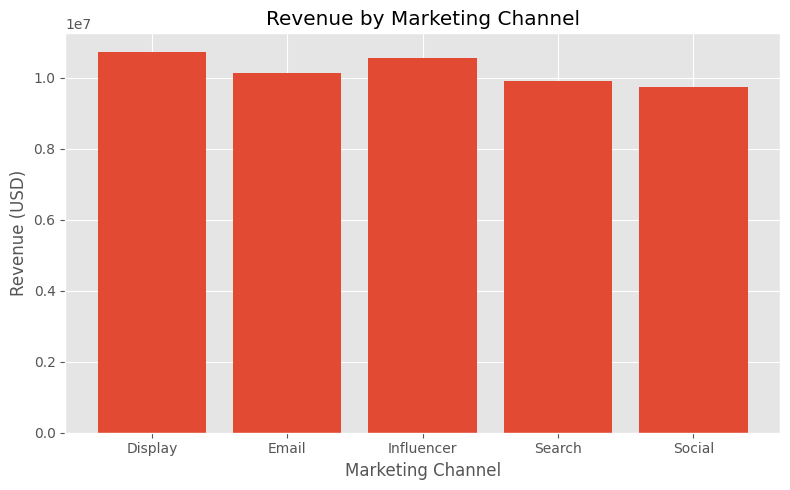

In [35]:
plt.figure(figsize=(8,5))

plt.bar(
    channel_summary["channel"],
    channel_summary["Total_Revenue"]
)

plt.title("Revenue by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Revenue (USD)")
plt.style.use("ggplot")
plt.tight_layout()
plt.show()

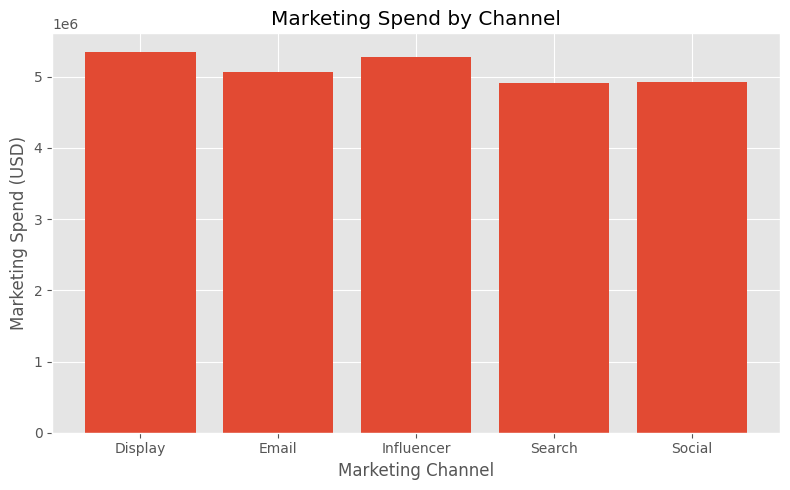

In [31]:
plt.figure(figsize=(8,5))

plt.bar(
    channel_summary["channel"],
    channel_summary["Marketing_Spend"]
)

plt.title("Marketing Spend by Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Marketing Spend (USD)")
plt.style.use("ggplot")
plt.tight_layout()
plt.show()

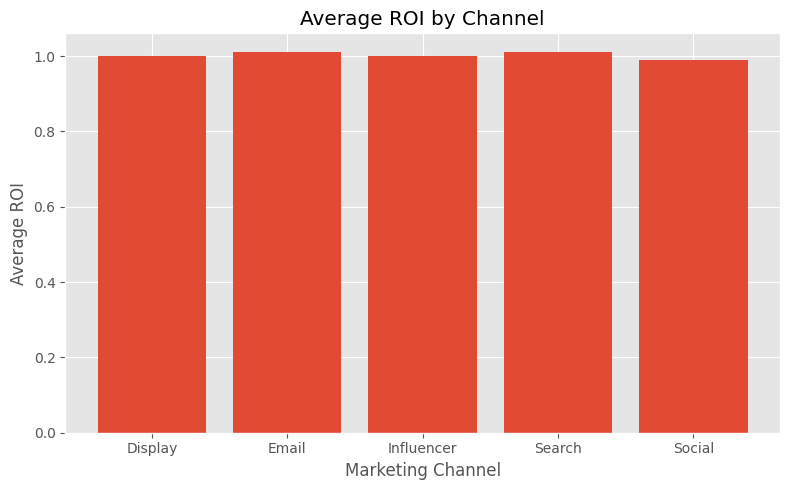

In [32]:
plt.figure(figsize=(8,5))

plt.bar(
    channel_summary["channel"],
    channel_summary["Average_ROI"]
)

plt.title("Average ROI by Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Average ROI")
plt.style.use("ggplot")
plt.tight_layout()
plt.show()

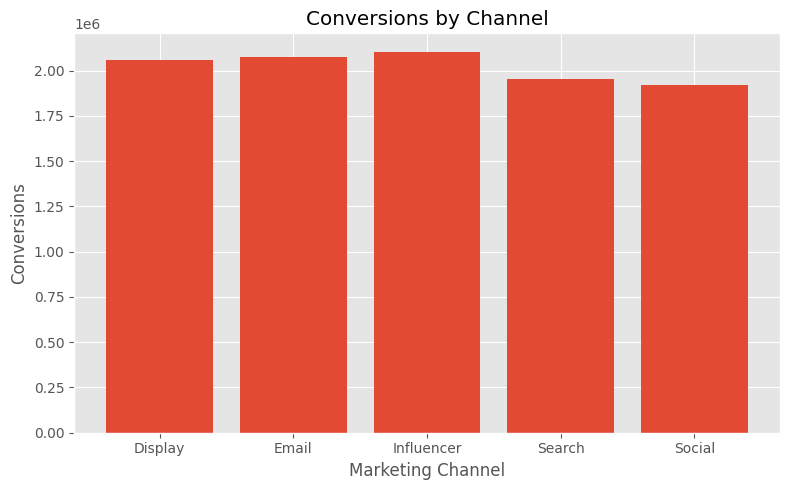

In [33]:
plt.figure(figsize=(8,5))

plt.bar(
    channel_summary["channel"],
    channel_summary["Total_Conversions"]
)

plt.title("Conversions by Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Conversions")
plt.style.use("ggplot")
plt.tight_layout()
plt.show()

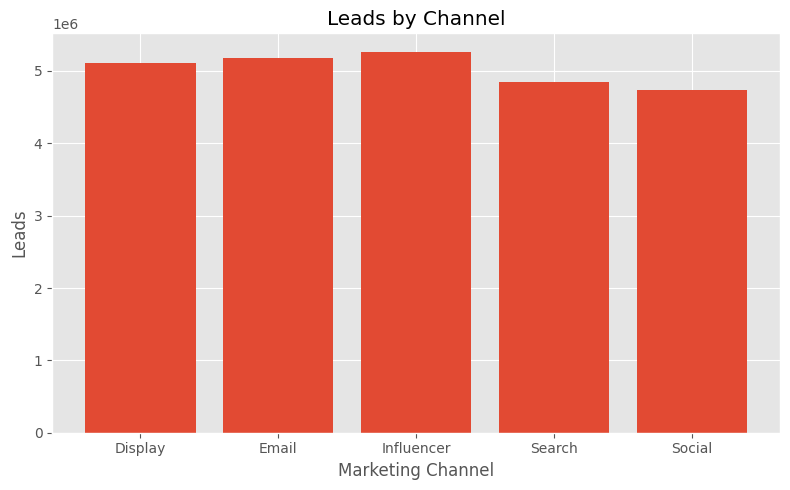

In [34]:
plt.figure(figsize=(8,5))

plt.bar(
    channel_summary["channel"],
    channel_summary["Total_Leads"]
)

plt.title("Leads by Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Leads")
plt.style.use("ggplot")
plt.tight_layout()
plt.show()

## Marketing Funnel Analysis

This section evaluates how effectively each marketing channel moves prospects through the acquisition funnel.

Three key efficiency metrics are calculated:

- Click-Through Rate (CTR)
- Lead Conversion Rate
- Customer Conversion Rate

Unlike total counts, these percentages normalize performance across channels, enabling a fair comparison of marketing effectiveness regardless of campaign volume or budget.

In [37]:
channel_funnel = (
    df.groupby("channel", observed=False)
      .agg(
          Impressions=("impressions", "sum"),
          Clicks=("clicks", "sum"),
          Leads=("leads", "sum"),
          Conversions=("conversions", "sum")
      )
      .reset_index()
)

In [38]:
channel_funnel["CTR (%)"] = (
    channel_funnel["Clicks"] /
    channel_funnel["Impressions"]
) * 100

channel_funnel["Lead Conversion (%)"] = (
    channel_funnel["Leads"] /
    channel_funnel["Clicks"]
) * 100

channel_funnel["Customer Conversion (%)"] = (
    channel_funnel["Conversions"] /
    channel_funnel["Leads"]
) * 100

channel_funnel = channel_funnel.round(2)

channel_funnel

,channel,Impressions,Clicks,Leads,Conversions,CTR (%),Lead Conversion (%),Customer Conversion (%)
0,Display,309367070,16860249,5104763,2057607,5.45,30.28,40.31
1,Email,309167794,17125101,5182690,2076423,5.54,30.26,40.06
2,Influencer,322458407,17509829,5257189,2101198,5.43,30.02,39.97
3,Search,288572424,15932394,4843190,1951752,5.52,30.40,40.30
4,Social,293040684,15962360,4736804,1920020,5.45,29.67,40.53


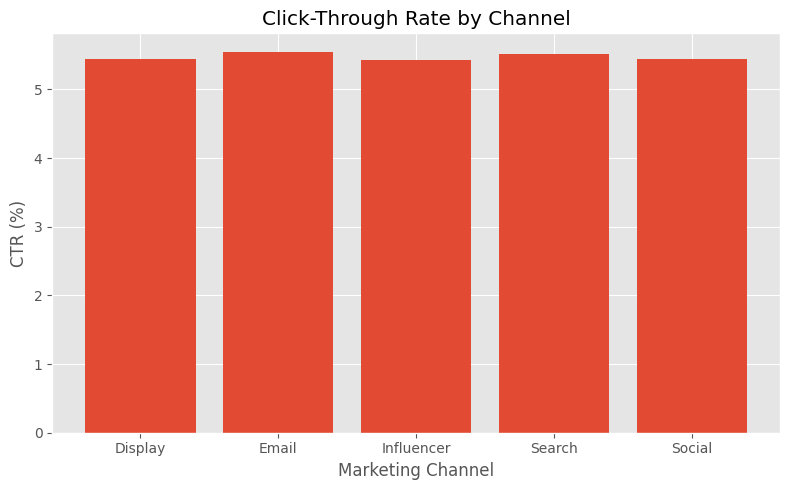

In [39]:
plt.figure(figsize=(8,5))

plt.bar(
    channel_funnel["channel"],
    channel_funnel["CTR (%)"]
)

plt.title("Click-Through Rate by Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("CTR (%)")

plt.tight_layout()
plt.show()

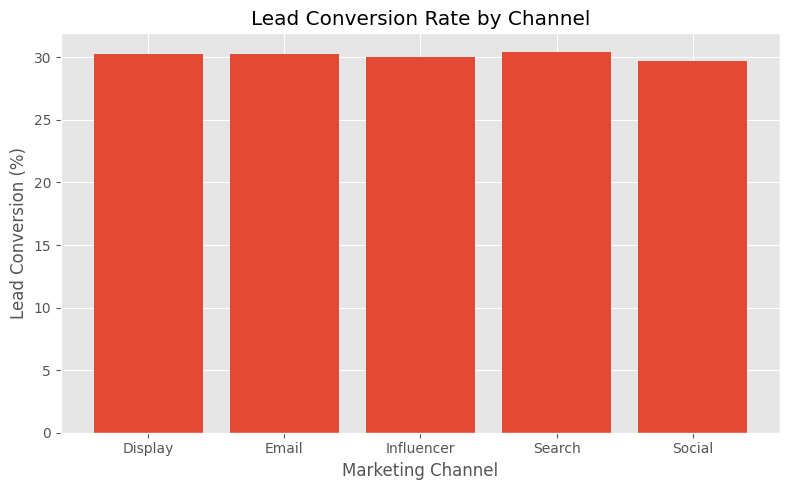

In [40]:
plt.figure(figsize=(8,5))

plt.bar(
    channel_funnel["channel"],
    channel_funnel["Lead Conversion (%)"]
)

plt.title("Lead Conversion Rate by Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Lead Conversion (%)")

plt.tight_layout()
plt.show()

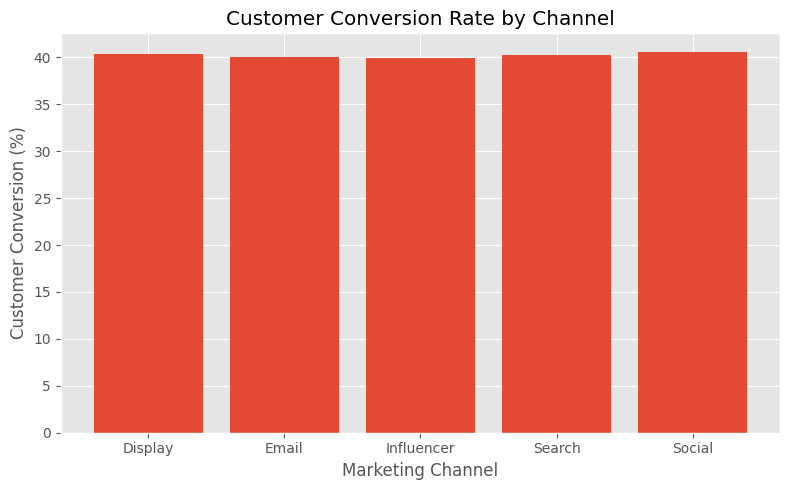

In [41]:
plt.figure(figsize=(8,5))

plt.bar(
    channel_funnel["channel"],
    channel_funnel["Customer Conversion (%)"]
)

plt.title("Customer Conversion Rate by Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Customer Conversion (%)")

plt.tight_layout()
plt.show()

## Revenue & Cost Analysis

This analysis compares marketing investment against the revenue generated across different channels.

Key financial metrics include:

- Total Marketing Spend
- Total Revenue
- Profit
- Revenue Generated per $1 Spent

These KPIs help identify which marketing channels deliver the strongest financial returns and where future marketing budgets should be allocated.

In [42]:
financial_summary = (
    df.groupby("channel", observed=False)
      .agg(
          Total_Spend=("cost_usd", "sum"),
          Total_Revenue=("revenue_usd", "sum")
      )
      .reset_index()
)

financial_summary["Profit"] = (
    financial_summary["Total_Revenue"]
    - financial_summary["Total_Spend"]
)

financial_summary["Revenue per $1 Spent"] = (
    financial_summary["Total_Revenue"]
    / financial_summary["Total_Spend"]
)

financial_summary = financial_summary.round(2)

financial_summary

,channel,Total_Spend,Total_Revenue,Profit,Revenue per $1 Spent
0,Display,5343184.30,10715125.21,5371940.91,2.01
1,Email,5065029.98,10130542.61,5065512.63,2.00
2,Influencer,5278787.92,10558118.99,5279331.07,2.00
3,Search,4916568.46,9897677.79,4981109.33,2.01
4,Social,4919999.25,9725024.70,4805025.45,1.98


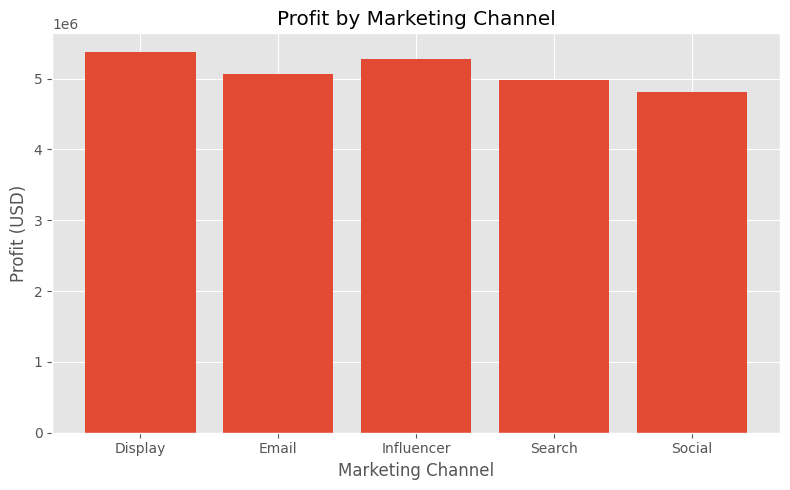

In [43]:
plt.figure(figsize=(8,5))

plt.bar(
    financial_summary["channel"],
    financial_summary["Profit"]
)

plt.title("Profit by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Profit (USD)")

plt.tight_layout()
plt.show()

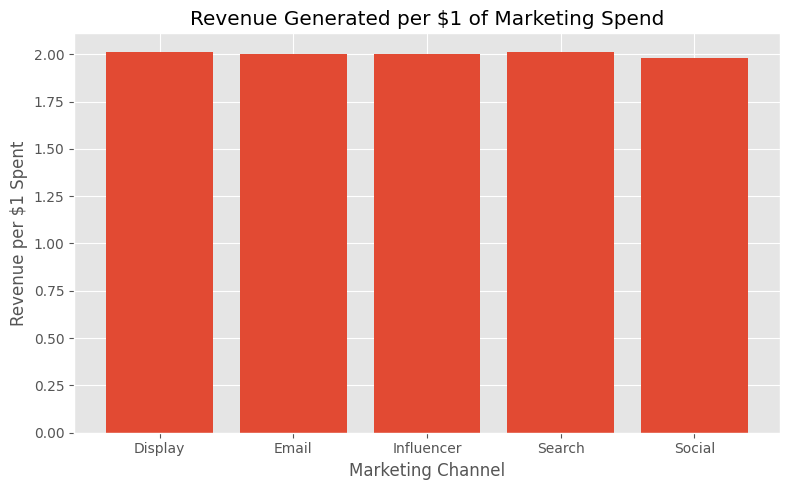

In [44]:
plt.figure(figsize=(8,5))

plt.bar(
    financial_summary["channel"],
    financial_summary["Revenue per $1 Spent"]
)

plt.title("Revenue Generated per $1 of Marketing Spend")
plt.xlabel("Marketing Channel")
plt.ylabel("Revenue per $1 Spent")

plt.tight_layout()
plt.show()

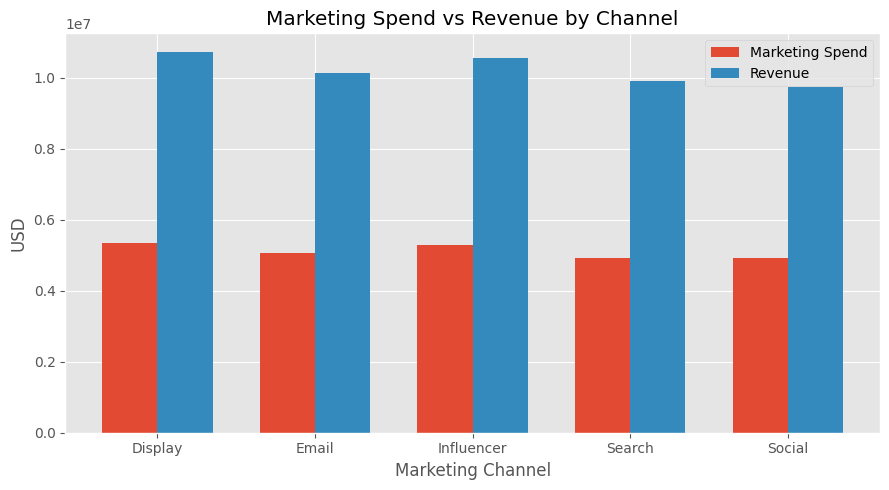

In [45]:
x = range(len(financial_summary))

width = 0.35

plt.figure(figsize=(9,5))

plt.bar(
    [i - width/2 for i in x],
    financial_summary["Total_Spend"],
    width=width,
    label="Marketing Spend"
)

plt.bar(
    [i + width/2 for i in x],
    financial_summary["Total_Revenue"],
    width=width,
    label="Revenue"
)

plt.xticks(x, financial_summary["channel"])

plt.title("Marketing Spend vs Revenue by Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("USD")

plt.legend()

plt.tight_layout()
plt.show()

## Time-Series Performance Analysis

This section evaluates how marketing performance evolves over time by aggregating campaign data on a monthly basis.

The analysis tracks four key performance indicators:

- Marketing Spend
- Revenue
- Conversions
- Average ROI

Trend analysis helps identify seasonality, periods of strong or weak performance, and whether changes in marketing investment are associated with changes in business outcomes.

In [46]:
df["month"] = df["startdate"].dt.to_period("M").astype(str)

df[["startdate", "month"]].head()

,startdate,month
0,2025-04-13,2025-04
1,2025-12-15,2025-12
2,2025-09-28,2025-09
3,2025-04-17,2025-04
4,2025-03-13,2025-03


In [47]:
monthly_summary = (
    df.groupby("month")
      .agg(
          Marketing_Spend=("cost_usd", "sum"),
          Revenue=("revenue_usd", "sum"),
          Conversions=("conversions", "sum"),
          Average_ROI=("roi", "mean")
      )
      .round(2)
      .reset_index()
)

monthly_summary

,month,Marketing_Spend,Revenue,Conversions,Average_ROI
0,2025-01,2121091.56,4321748.75,872983,1.01
1,2025-02,1958670.98,3917068.44,730725,1.01
2,2025-03,2163766.51,4355047.85,837286,1.01
3,2025-04,2270411.89,4583817.85,924076,1.02
4,2025-05,2250756.51,4533400.94,817599,1.01
5,2025-06,2086428.79,4080666.52,863365,0.98
6,2025-07,2138898.24,4239110.66,854471,1.01
7,2025-08,2185716.06,4390108.74,865415,1.01
8,2025-09,1993657.74,3960373.22,782284,0.97
9,2025-10,2146254.38,4363171.95,854254,1.03


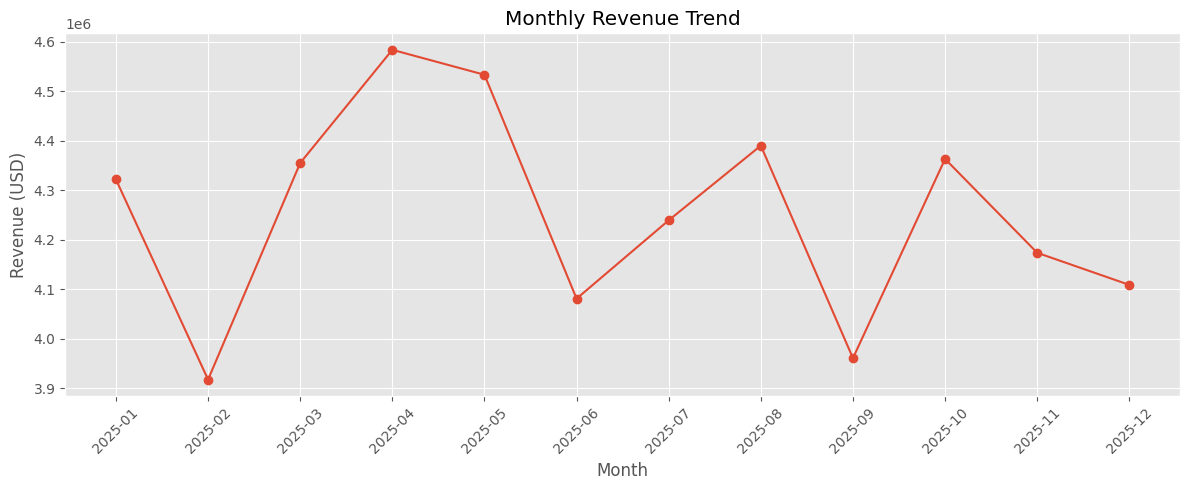

In [48]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_summary["month"],
    monthly_summary["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

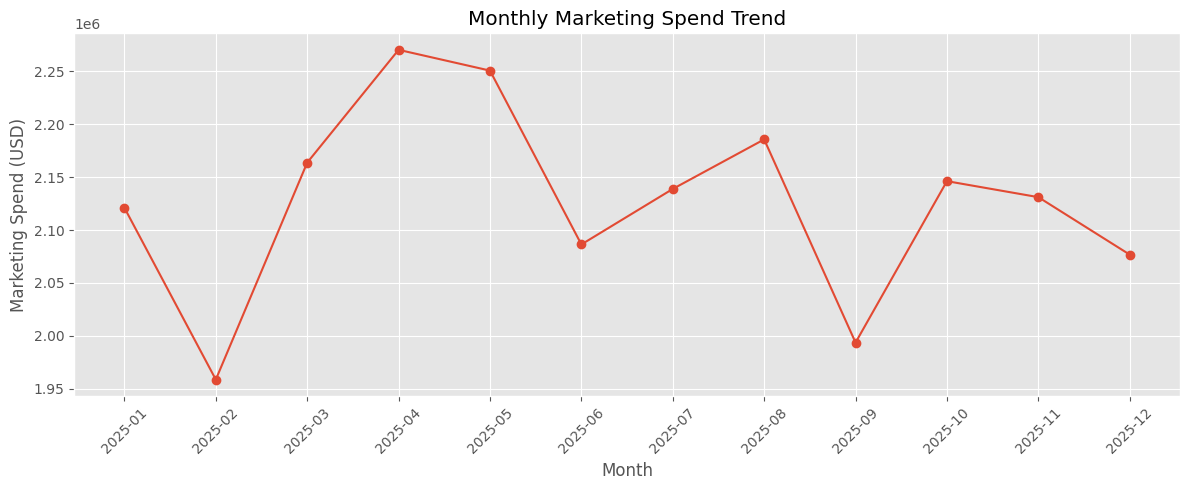

In [49]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_summary["month"],
    monthly_summary["Marketing_Spend"],
    marker="o"
)

plt.title("Monthly Marketing Spend Trend")
plt.xlabel("Month")
plt.ylabel("Marketing Spend (USD)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

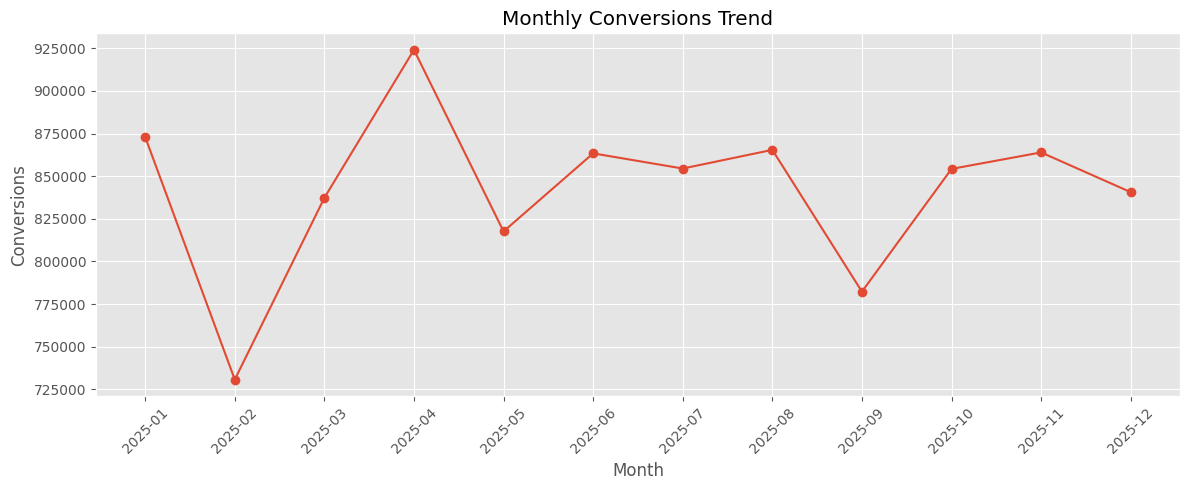

In [50]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_summary["month"],
    monthly_summary["Conversions"],
    marker="o"
)

plt.title("Monthly Conversions Trend")
plt.xlabel("Month")
plt.ylabel("Conversions")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

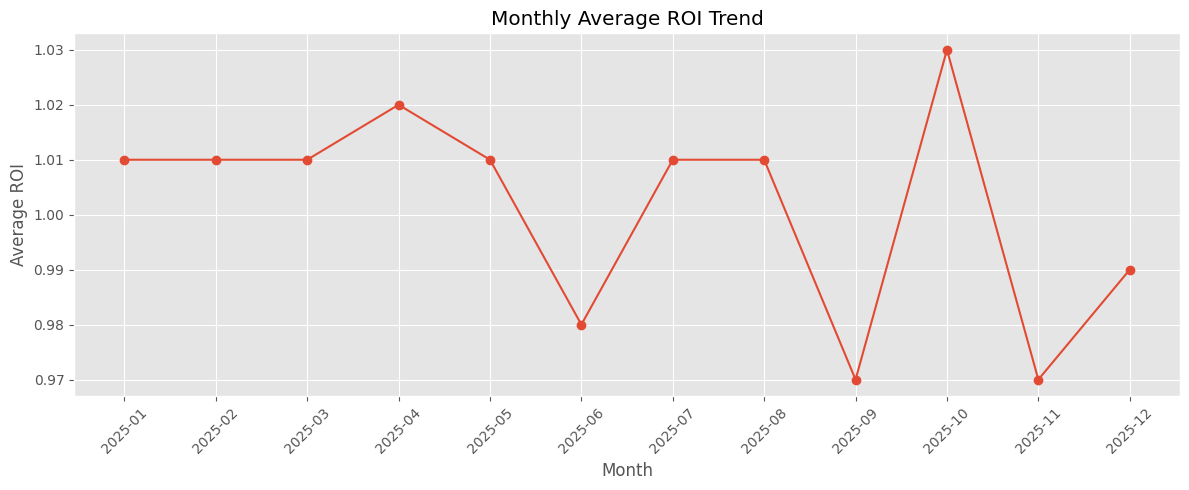

In [51]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_summary["month"],
    monthly_summary["Average_ROI"],
    marker="o"
)

plt.title("Monthly Average ROI Trend")
plt.xlabel("Month")
plt.ylabel("Average ROI")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Correlation Analysis – Business Insights

The correlation analysis identified several important relationships among the marketing metrics.

The strongest positive correlation was observed between **Leads** and **Conversions (r = 0.920)**, indicating that campaigns generating more qualified leads generally produce more customer conversions.

A strong relationship was also found between **Clicks** and **Leads (r = 0.852)**, suggesting that higher user engagement is associated with increased lead generation.

Marketing **Cost** and **Revenue** exhibited a strong positive correlation (r = 0.860), implying that higher marketing investment is generally accompanied by higher revenue generation. However, this should not be interpreted as a causal relationship.

Revenue displayed only a moderate correlation with **ROI (r = 0.439)**, indicating that high-revenue campaigns are not necessarily the most efficient. Evaluating campaign success therefore requires considering both financial returns and marketing efficiency.

Finally, marketing spend showed little relationship with impressions, clicks, leads, and conversions, suggesting that campaign effectiveness depends on factors beyond advertising budget alone, such as channel selection, creative quality, and audience targeting.

In [53]:
numeric_df = df[[
    "impressions",
    "clicks",
    "leads",
    "conversions",
    "cost_usd",
    "revenue_usd",
    "roi"
]]

correlation_matrix = numeric_df.corr()

correlation_matrix

,impressions,clicks,leads,conversions,cost_usd,revenue_usd,roi
impressions,1.000000,0.719330,0.615934,0.566806,-0.021056,-0.015958,0.009158
clicks,0.719330,1.000000,0.851751,0.786610,-0.014865,-0.006921,0.015015
leads,0.615934,0.851751,1.000000,0.920206,-0.012583,-0.004509,0.022152
conversions,0.566806,0.786610,0.920206,1.000000,-0.016001,-0.006510,0.020949
cost_usd,-0.021056,-0.014865,-0.012583,-0.016001,1.000000,0.859691,-0.007188
revenue_usd,-0.015958,-0.006921,-0.004509,-0.006510,0.859691,1.000000,0.438801
roi,0.009158,0.015015,0.022152,0.020949,-0.007188,0.438801,1.000000


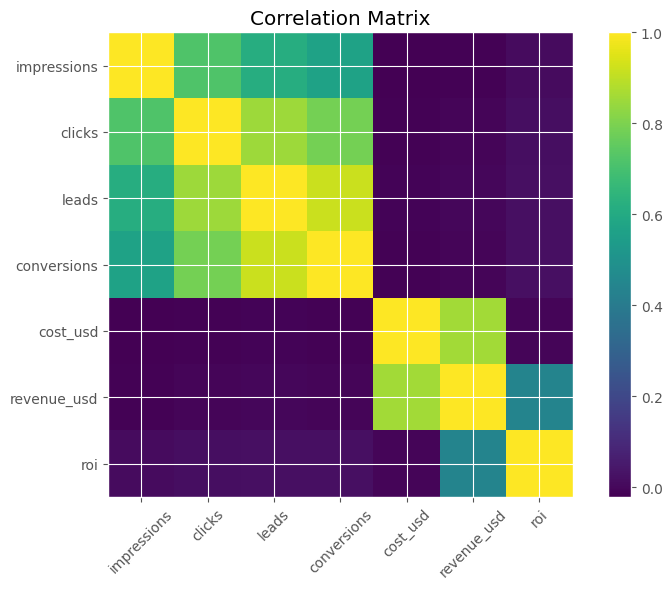

In [54]:
plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix, interpolation="nearest")

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()